# Data5441 - Networks and High-dimensional Inference 
Semester 2, 2026

# Tutorial Week 7


The goals of this tutorial and assignment are to learn more about:
- the Stochastic Block Model (SBM) family of random graphs.
- computational techniques for inference that allow us to apply SBMs to data.

This will be done considering the simple and illustrative example of the Karate Club network with $B=2$ blocks (communities).


In [116]:
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx

SEED = 5441
rng = np.random.default_rng(SEED)

gk = nx.karate_club_graph()
layout = nx.spring_layout(gk, seed=13)
N = gk.number_of_nodes()

print("Karate Club Netwrok Global Clustering Coefficient:",nx.transitivity(gk))

Karate Club Netwrok Global Clustering Coefficient: 0.2556818181818182


# Introduction

The **Stochastic Block Model (SBM)** is a probabilistic model used to represent community structure in networks. In an SBM, each node belongs to one of $B$ latent groups, and the probability of an edge between two nodes depends solely on their group memberships. Formally, let $A_{ij}$ be the adjacency matrix entry indicating the presence of an edge between nodes $i$ and $j$, and let $b_i,b_j \in \{1,2, \ldots, B\}$ denote their group assignments. Then,
$$
P(A_{ij} = 1 \mid b_i, b_j) = P_{b_i, b_j},
$$  
where $P_{r,s}$ is a $B \times B$ matrix of connection probabilities between groups. SBMs are widely used for tasks such as community detection and inference of large-scale network structure.


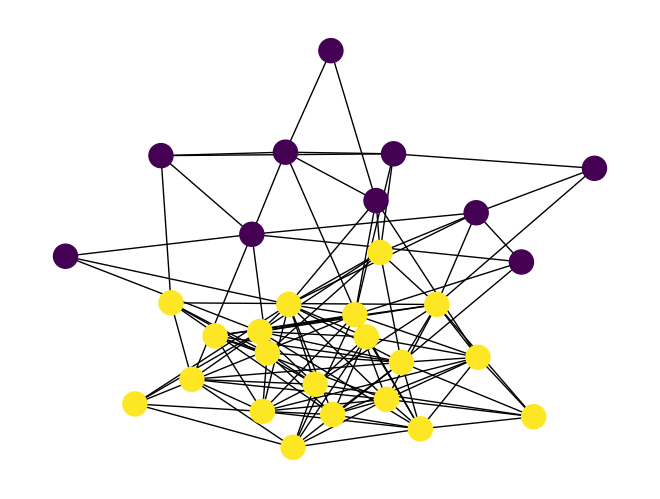

In [117]:
N0 = 10
N1 = 20
sizes = [N0, N1]  # two communities, one with N0 nodes and one with N1 nodes
p = [[0.3, 0.1], [0.1, 0.4]]  # intra- and inter-community connection probabilities
G = nx.stochastic_block_model(sizes, p, seed=13)
b = np.concatenate((np.zeros(N0), np.ones(N1)))
nx.draw(G, node_color=b, pos=nx.spring_layout(G, seed=13))


As derived in class, the negative log-likelihood of an SBM generating a given network can be written as

$$
-\log \mathcal{L} = -\sum_{r \geq s}\left[\ell_{r,s}\log\left(\frac{\ell_{r,s}}{y_{r,s}}\right)
+(y_{r,s}-\ell_{r,s})\log\left(1-\frac{\ell_{r,s}}{y_{r,s}}\right)\right],
$$

where $\ell_{r,s}$ is the number of edges between blocks $r,s$ and $y_{r,s}$ is the maximum possible number of edges. This function can be coded for $B=2$ as:


In [118]:
def minusLogL(L, Ns):
    """Negative log-likelihood for an SBM with B=2; L contains edge counts and Ns contains block sizes."""
    N0 = Ns[0]
    N1 = Ns[1]
    Y = [N0*(N0-1)/2., N0*N1, N1*(N1-1)/2.]  # maximum numbers of edges
    s = 0
    for i in range(3):
        if L[i] > 0 and L[i] != Y[i]:  # only add terms that are neither empty nor full
            s += L[i]*np.log(L[i]/Y[i]) + (Y[i]-L[i])*np.log(1-L[i]/Y[i])
    return -s


## SBM for different partitions of the Karate Club

When using SBMs to describe a real network, the key parameters are the node assignments
$$
\vec{b}=\{b_1,b_2,\ldots,b_N\}.
$$
Once $\vec{b}$ is fixed, the quantities $\ell_{r,s}$ and $y_{r,s}$ are computed from the numbers of nodes within groups and edges between groups.

Here we compute the properties of SBMs for different partitions $\vec{b}$ of the Karate Club. We initially consider three possible partitions, and later discuss how to find and sample better partitions. We start by writing a function that computes the negative log-likelihood after counting the edges between groups:


In [119]:
def computeMinusLogL(gk, b):
    edges = [0, 0, 0]  # edge counts for block pairs 00, 01, and 11
    for e in gk.edges():
        index = b[e[0]] + b[e[1]]
        edges[index] += 1
    N0 = b.count(0)
    N1 = b.count(1)
    return minusLogL(edges, [N0, N1])

## Partition 1: all nodes in one block $\vec{b}_0$


In [120]:
b0=[0 for i in range(N)]
computeMinusLogL(gk,b0)

np.float64(226.20209580225185)

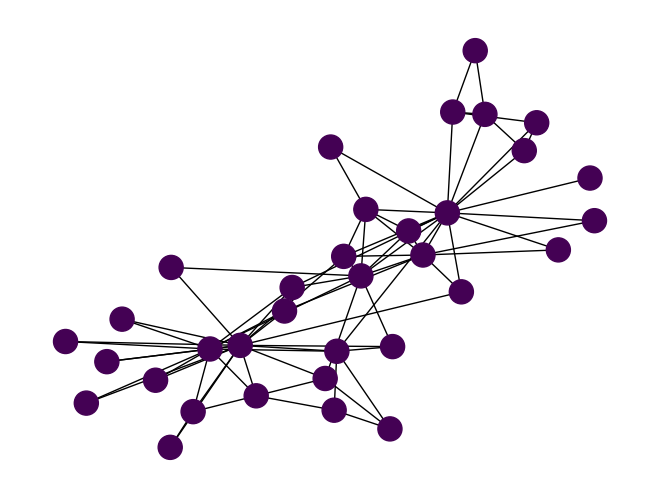

In [121]:
nx.draw(gk,node_color=b0, pos=layout)

## Partition 2: random partition (seed 13), $\vec{b}_{r}$

One random assignment of the nodes to two blocks:


In [122]:
np.random.seed(13)
br=[np.random.randint(2) for i in range(N)]
computeMinusLogL(gk,br)

np.float64(224.08815629080152)

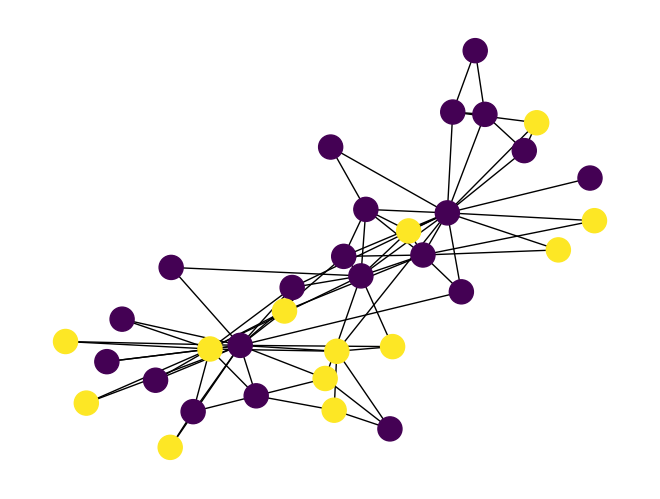

In [123]:
nx.draw(gk,node_color =br, pos=layout)

## Partition 3: the club split partition $\vec{b}_{club}$


In [124]:
bclub=[]
for i in range(N):
    if gk.nodes[i]['club']=="Mr. Hi":
        bclub.append(0)
    else:
        bclub.append(1)

In [125]:
computeMinusLogL(gk,bclub)

np.float64(198.49936742452917)

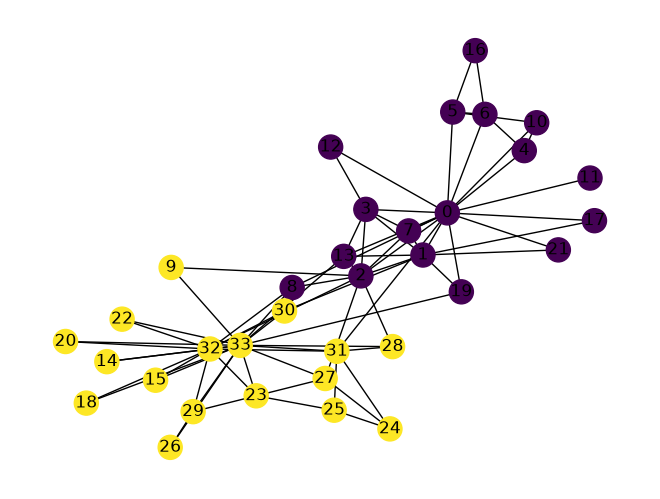

In [126]:
nx.draw(gk,node_color=bclub, pos=layout, with_labels=True)

# Exercises


## Exercise 1. Exploring SBMs with given partitions

Here we explore and compare SBMs with the partitions introduced above: $\vec{b}_{0}, \vec{b}_r, \vec{b}_{club}$.

- a) Rank the three partitions from best to worst, according to the likelihood that the data were generated by the corresponding SBM.

best to worst: $b_\text{club}, b_r, b_0$

- b) Which random-graph model is equivalent to the SBM with $\vec{b}_0$?

Erdos-Renyi

- c) Compute the probabilities $P_{r,s}$ for each of the three partitions. For a two-block model, $P=[[p_{0,0},p_{0,1}],[p_{1,0},p_{1,1}]]$.

- d) What is the expected global clustering coefficient (transitivity) $C$ of the SBM with $\vec{b}_0, \vec{b}_r, \vec{b}_{club}$? Compare these values with the transitivity of the Karate Club network.


In [127]:
def expected_global_clustering(P, block_sizes):
    P = np.asarray(P)

    B = len(block_sizes)
    numerator = 0.0
    denominator = 0.0

    for r in range(B):
        for s in range(B):
            for t in range(B):

                N_rst = (
                    block_sizes[r]
                    * (block_sizes[s] - int(s == r))
                    * (block_sizes[t] - int(t == r) - int(t == s))
                )

                # Probability that r-s-t forms a wedge
                wedge_prob = P[r, s] * P[s, t]

                # Probability that the wedge is closed
                closed_prob = wedge_prob * P[r, t]

                denominator += N_rst * wedge_prob
                numerator += N_rst * closed_prob

    return numerator / denominator

In [128]:
n0 = sum(np.array(b0) == 0)
m00 = gk.number_of_edges()
p00 = m00 / (n0 * (n0 - 1) / 2)

P = np.array([[p00]])
expected_clustering_b0 = expected_global_clustering(P, [n0])

print(P)
print("Expected clustering coefficient for b0:", expected_clustering_b0)

[[0.13903743]]
Expected clustering coefficient for b0: 0.13903743315508021


In [129]:
# b_r
n0 = sum(np.array(br) == 0)
n1 = sum(np.array(br) == 1)

m00 = 0
m01 = 0
m11 = 0

for u, v in gk.edges():
    if br[u] == 0 and br[v] == 0:
        m00 += 1
    elif br[u] == 1 and br[v] == 1:
        m11 += 1
    else:
        m01 += 1

p00 = m00 / (n0 * (n0 - 1) / 2)
p01 = m01 / (n0 * n1)
p11 = m11 / (n1 * (n1 - 1) / 2)

P = np.array([
    [p00, p01],
    [p01, p11]
])

print("P for b_r:", P)

expected_clustering_br = expected_global_clustering(P, [n0, n1])
print("Expected clustering coefficient for b_r:", expected_clustering_br)

P for b_r: [[0.16666667 0.13553114]
 [0.13553114 0.07692308]]
Expected clustering coefficient for b_r: 0.14387668010980265


In [130]:
# b_club
n0 = sum(np.array(bclub) == 0)
n1 = sum(np.array(bclub) == 1)

m00 = 0
m01 = 0
m11 = 0

for u, v in gk.edges():
    if bclub[u] == 0 and bclub[v] == 0:
        m00 += 1
    elif bclub[u] == 1 and bclub[v] == 1:
        m11 += 1
    else:
        m01 += 1

p00 = m00 / (n0 * (n0 - 1) / 2)
p01 = m01 / (n0 * n1)
p11 = m11 / (n1 * (n1 - 1) / 2)

P = np.array([
    [p00, p01],
    [p01, p11]
])

print("P for b_club:", P)

expected_clustering_bclub = expected_global_clustering(P, [n0, n1])
print("Expected clustering coefficient for b_club:", expected_clustering_bclub)

P for b_club: [[0.25735294 0.03806228]
 [0.03806228 0.23529412]]
Expected clustering coefficient for b_club: 0.19415591099920348


## Exercise 2. Finding good block partitions

Here we are interested in finding good SBM partitions $\vec{b}$ with $B=2$ for the Karate Club. We start by estimating computational costs.

- a) How many possible partitions with exactly $B=2$ non-empty blocks are there for the Karate Club network? How does the number of partitions depend on the numbers of nodes $N$ and groups $B$?


In [131]:
from sympy.functions.combinatorial.numbers import stirling
print(f"Stirling number of the second kind S({N}, 2): {int(stirling(N, 2)):,}")

Stirling number of the second kind S(34, 2): 8,589,934,591


- b) Estimate how long your computer would take to exhaustively check all possible partitions. Hint: type `%%timeit` at the start of a cell to quantify the time taken by operations.

In [132]:
%%timeit
computeMinusLogL(gk, br)

18.8 μs ± 509 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


In [133]:
num_partitions = stirling(34, 2)
time_per_partition = 18.5e-6  

total_seconds = num_partitions * time_per_partition
print("Seconds:", total_seconds)
print("Hours:", total_seconds / 3600)
print("Days:", total_seconds / (3600 * 24))

Seconds: 158913.789933500
Hours: 44.1427194259722
Days: 1.83927997608218


- c) What is the best partition $\vec{b}$ you can find using any strategy you can think of? Report its negative log-likelihood.

In [134]:
degrees = [gk.degree(node) for node in gk.nodes()]
sorted_nodes = sorted(gk.nodes(), key=lambda x: degrees[x], reverse=True)
core_nodes = sorted_nodes[:5]

b_core_per = []
for i in range(N):
    if i in core_nodes:
        b_core_per.append(1)
    else:
        b_core_per.append(0)

print(b_core_per)
computeMinusLogL(gk, b_core_per)

[1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1]


np.float64(179.3891968406941)

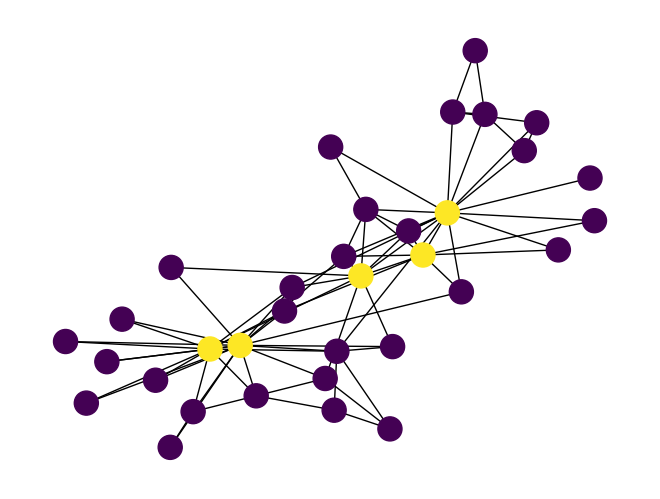

In [135]:
nx.draw(gk,node_color=b_core_per, pos=layout)

## Exercise 3. Greedy algorithm



In order to design improved search (optimization) methods, we consider as a simple proposal the case of switching the block assignment of one node:



In [136]:
def switchOne(b,i):
    bcopy=b[:]
    if bcopy[i]==1:
        bcopy[i]=0
    else:
        bcopy[i]=1
    return bcopy

A greedy search consists of:

1. Go through all nodes $i=1,\ldots,N$ and check the extent to which switching each node improves the partition.
2. Perform the best single change found in step 1 (choose randomly in case of ties).
3. Repeat these steps until no improvement is found.

- a) Starting from the three partitions considered in Exercise 1 and from the best partition found in Exercise 2, check whether a single change improves them.
- b) Apply the greedy method starting from each partition and store the final partition obtained. Do they lead to the same final partition?
- c) Apply the greedy method from different random initial conditions and retain the best partition found, including those from the previous question. Denote it by $\vec{b}_{best}$.
- d) Characterize $\vec{b}_{best}$:
  - What is its negative log-likelihood?
  - Plot the partition and interpret why the nodes were grouped in this way.
  - Compute $P_{r,s}$ and determine whether the partition is assortative ($P_{0,0}$ and $P_{1,1}>P_{0,1}$), disassortative ($P_{0,0}$ and $P_{1,1}<P_{0,1}$), or core-periphery (otherwise).


In [137]:
def greedy_partition_search(g, b_init):
    b = b_init.copy()

    current_nll = computeMinusLogL(g, b)
    nll_history = [current_nll]

    while True:
        best_nll = current_nll
        best_b = None

        for i in range(len(b)):
            b_candidate = switchOne(b, i)
            candidate_nll = computeMinusLogL(g, b_candidate)

            if candidate_nll < best_nll:
                best_nll = candidate_nll
                best_b = b_candidate

        if best_b is None:
            break

        b = best_b
        current_nll = best_nll
        nll_history.append(current_nll)

    return b, nll_history

bmin_0: [1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1]
Final NLL: 179.3891968406941
bmin_r: [0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0]
Final NLL: 188.82814468080159
bmin_club: [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Final NLL: 196.28738515968246
bmin_core: [1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1]
Final NLL: 179.3891968406941 



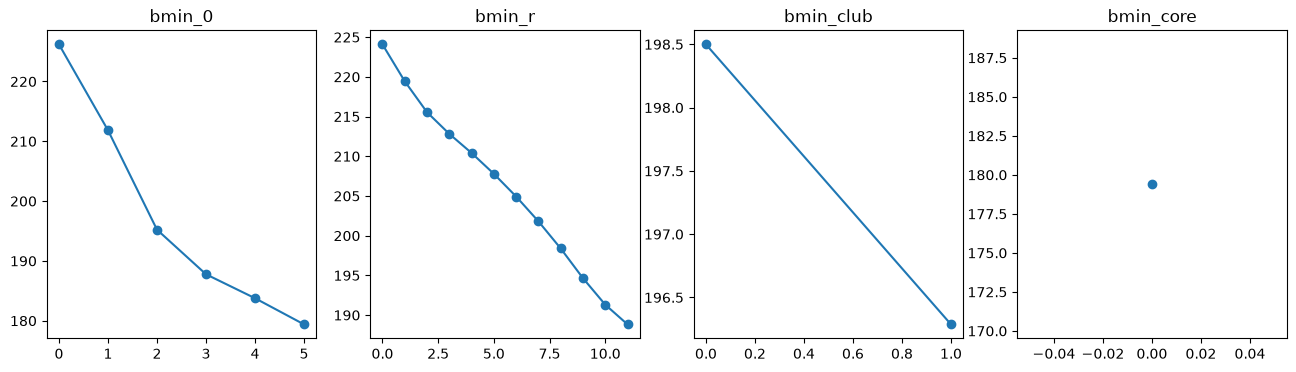

In [138]:
bmin_0, history_0 = greedy_partition_search(gk, b0)
bmin_r, history_r = greedy_partition_search(gk, br)
bmin_club, history_club = greedy_partition_search(gk, bclub)
bmin_core, history_core = greedy_partition_search(gk, b_core_per)

print("bmin_0:", bmin_0, )
print("Final NLL:", history_0[-1])
print("bmin_r:", bmin_r)
print("Final NLL:", history_r[-1])
print("bmin_club:", bmin_club)
print("Final NLL:", history_club[-1])
print("bmin_core:", bmin_core)
print("Final NLL:", history_core[-1], "\n")

fig, ax = plt.subplots(1, 4, figsize=(16, 4))

ax[0].plot( history_0, marker='o')
ax[0].set_title("bmin_0")
ax[1].plot(history_r, marker='o')
ax[1].set_title("bmin_r")
ax[2].plot(history_club, marker='o')
ax[2].set_title("bmin_club")
ax[3].plot(history_core, marker='o')
ax[3].set_title("bmin_core")

plt.show()


## Exercise 4. Local minima



Here we explore how the **greedy algorithm** can become trapped in local minima. In Exercise 3, applying the greedy algorithm from different initial conditions led to final block allocations $\vec{b}\neq\vec{b}_{best}$. These are local minima because they cannot be improved by any single-node move. One example is $\vec{b}_{min}=$




In [139]:
bmin_lm=[1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1]

- a) Check that $\vec{b}_{min}$ is a local minimum of the negative log-likelihood under the single-switch proposal.
- b) How many node allocations must be changed to map $\vec{b}_{min}$ to $\vec{b}_{best}$?
- c) Which single-node switch increases the negative log-likelihood the least (the smallest barrier)?
- d) Apply the switch from the previous question and check whether the greedy algorithm applied to this modified allocation leads to $\vec{b}_{best}$.


Best partition: [1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1]
Final NLL: 189.16510861180933


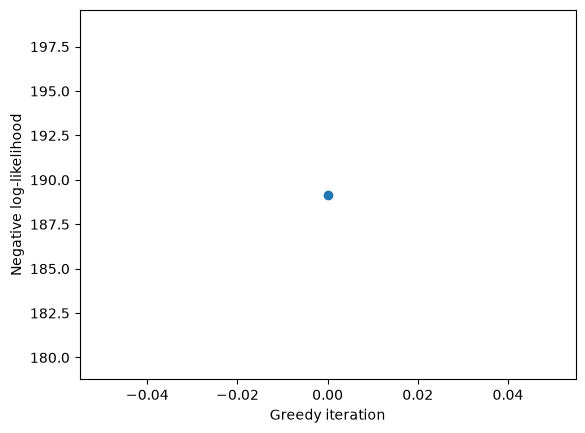

In [140]:
bmin, history = greedy_partition_search(gk, bmin_lm)

print("Best partition:", bmin)
print("Final NLL:", computeMinusLogL(gk, bmin))

plt.plot(history, marker='o')
plt.xlabel("Greedy iteration")
plt.ylabel("Negative log-likelihood")
plt.show()

## Exercise 5. Metropolis MCMC to sample and optimize SBMs

Metropolis MCMC can sample partitions $\vec{b}$ according to their likelihood. Using a single-node proposal, let
$$\Delta[-\log\mathcal{L}]=[-\log\mathcal{L}(\vec{b}')]-[-\log\mathcal{L}(\vec{b})].$$
The Metropolis acceptance probability is
$$
A(\vec{b}\mapsto\vec{b}')=\min\left\{1,\frac{\mathcal{L}(\vec{b}')}{\mathcal{L}(\vec{b})}\right\}
=\min\left\{1,e^{-\Delta[-\log\mathcal{L}]}\right\}.
$$
Thus, moves to worse partitions can still be accepted, helping the chain escape local minima.

- a) What is the acceptance probability in the simple Metropolis algorithm ($\beta=1$) for the uphill move along the path from $\vec{b}_{min}$ to $\vec{b}_{best}$ considered above?
- b) Implement Metropolis MCMC from a random initial condition such as $\vec{b}_r$. Plot the negative log-likelihood for $t\in[0,1000]$.
- c) Was $\vec{b}_{best}$ visited by your MCMC sampler? Could this method be used to find $\vec{b}_{best}$?


In [189]:
def Pi(b, B, rng):
    # For B=1, there is no other block to move to
    if B == 1:
        return b.copy(), False

    b_new = b.copy()
    i = rng.integers(len(b))
    old_block = b[i]

    # Reject if moving this node would empty its block
    if np.sum(b == old_block) == 1:
        return b.copy(), False

    # Choose one of the other B-1 blocks
    new_blocks = [r for r in range(B) if r != old_block]
    b_new[i] = rng.choice(new_blocks)

    return b_new, True


def mcmc_partition_search(g, B, b_init, n_steps=1000, seed=SEED):
    rng = np.random.default_rng(seed)

    b = np.array(b_init).copy()
    current_nll = computeMinusLogL(g, b)

    nll_history = [current_nll]
    partition_history = [b.copy()]
    accepted = 0

    for _ in range(n_steps):
        b_new, valid = Pi(b, B, rng)

        if valid:
            new_nll = computeMinusLogL(g, b_new)
            delta_E = new_nll - current_nll
            acceptance_prob = min(1.0, np.exp(-delta_E))

            if rng.random() < acceptance_prob:
                b = b_new
                current_nll = new_nll
                accepted += 1

        nll_history.append(current_nll)
        partition_history.append(b.copy())

    return b, np.array(nll_history), partition_history, accepted

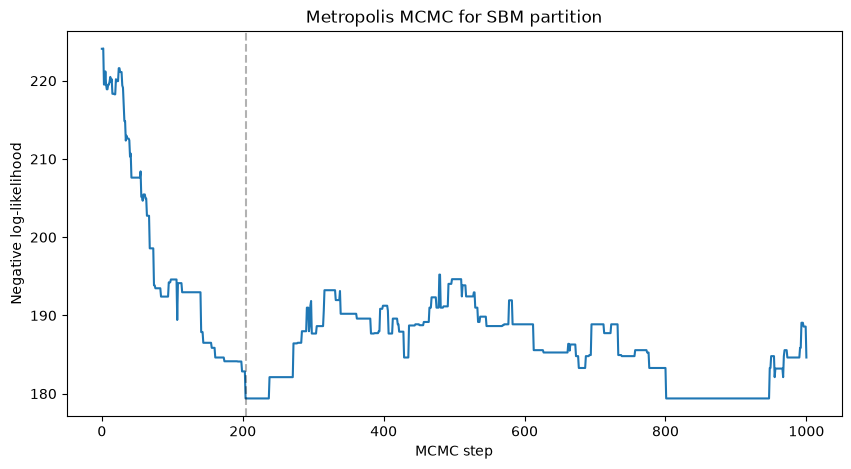

Acceptance rate: 0.132
Best NLL visited: 179.3891968406941 (at step 204)


In [160]:
b_final, nll_history, partition_history, accepted = mcmc_partition_search(gk, 2, br, n_steps=1000, seed=13)
min_step = np.argmin(nll_history)

plt.figure(figsize=(10, 5))
plt.plot(range(len(nll_history)), nll_history)
plt.axvline(min_step, color='black', linestyle='--', alpha=0.3)

plt.xlabel("MCMC step")
plt.ylabel("Negative log-likelihood")
plt.title("Metropolis MCMC for SBM partition")
plt.show()

print("Acceptance rate:", accepted / 1000)
print(f"Best NLL visited: {np.min(nll_history)} (at step {min_step})")

## Exercise 6. Comparing the SBM likelihood for different values of $B$

Here we generalize our analysis of Stochastic Block Models (SBMs) from $B=2$ to an arbitrary number of blocks. We will use this generalization to infer both the partition and the number of blocks $B$ by Bayesian model comparison.

We first generalize the greedy search to find good partitions for fixed $B$, that is, to minimize the negative log-likelihood

$$
-\log\mathcal{L}=-\sum_{r\geq s}\left[\ell_{r,s}\log\frac{\ell_{r,s}}{y_{r,s}}
+(y_{r,s}-\ell_{r,s})\log\left(1-\frac{\ell_{r,s}}{y_{r,s}}\right)\right],
$$

where $\ell_{r,s}$ is the number of edges between blocks $r,s$ and $y_{r,s}$ is the maximum possible number of edges.

a) Implement this function for partitions with an arbitrary number of non-empty groups, $1\leq B\leq N$.

b) Test it for $B=2$ and $B=3$ on the Karate Club network.

In [143]:
def relabel_partition(b):
    labels = np.unique(b)
    mapping = {label: i for i, label in enumerate(labels)}
    return np.array([mapping[x] for x in b], dtype=int)

def block_sizes(b):
    B = len(np.unique(b))
    return np.array([np.sum(b == r) for r in range(B)])

def calc_ell(g, b):
    B = len(np.unique(b))
    ell = np.zeros((B, B), dtype=int)

    for u, v in g.edges():
        r = b[u]
        s = b[v]
        if r > s:
            r, s = s, r
        ell[r, s] += 1
    return ell

def calc_y(n, r, s):
    if r == s:
        return n[r] * (n[r] - 1) // 2
    return n[r] * n[s]


def computeMinusLogL(g, b):
    b = relabel_partition(b)
    n = block_sizes(b)
    ell = calc_ell(g, b)
    B = len(n)
    nll = 0.0

    for r in range(B):
        for s in range(r, B):
            y_rs = calc_y(n, r, s)
            ell_rs = ell[r, s]

            if y_rs == 0:
                continue

            p_rs = ell_rs / y_rs

            if ell_rs > 0:
                nll -= ell_rs * np.log(p_rs)
            if ell_rs < y_rs:
                nll -= (y_rs - ell_rs) * np.log(1 - p_rs)

    return nll

def fit_probability_matrix(g, b):
    b = relabel_partition(b)
    n = block_sizes(b)
    ell = calc_ell(g, b)
    B = len(n)
    P = np.zeros((B, B), dtype=float)

    for r in range(B):
        for s in range(r, B):
            y_rs = calc_y(n, r, s)

            if y_rs > 0:
                P[r, s] = ell[r, s] / y_rs
                P[s, r] = P[r, s]

    return P

Final partition:
[1 1 1 0 2 2 2 0 0 0 2 2 0 0 0 0 2 0 0 0 2 2 0 2 2 2 2 2 2 2 0 2 1 1]
Final NLL: 159.0205098130844
Best NLL visited: 158.38808172993066
Acceptance rate: 0.198


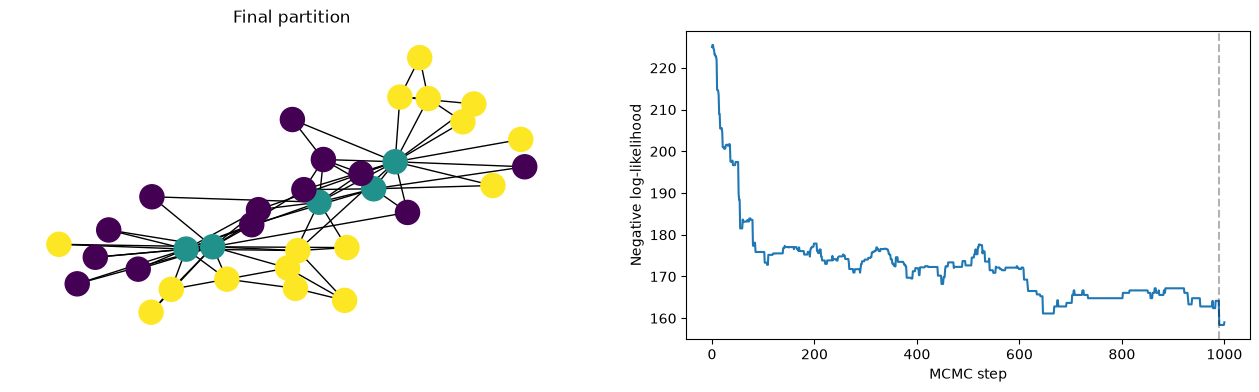

In [ ]:
b_init = rng.integers(3, size=gk.number_of_nodes())
b_final, nll_history, partition_history, accepted = mcmc_partition_search(gk, 3, b_init, n_steps=1000, seed=SEED)
final_nll_pos = np.argmin(nll_history)

print("Final partition:")
print(b_final)

print("Final NLL:", nll_history[-1])
print("Best NLL visited:", np.min(nll_history))
print("Acceptance rate:", accepted / 1000)

fig, ax = plt.subplots(1, 2, figsize=(16, 4))
nx.draw(gk, node_color=b_final, pos=layout, ax=ax[0])
ax[0].set_title("Final partition")
ax[1].plot(nll_history)
ax[1].axvline(final_nll_pos, color='black', linestyle='--', alpha=0.3)
ax[1].set_xlabel("MCMC step")
ax[1].set_ylabel("Negative log-likelihood")
plt.show()

In [227]:
Bs = [1,2,3,34]

for B in Bs:
    if B != 34:
        b_init = rng.integers(B, size=gk.number_of_nodes())
    else:
        b_init = np.arange(N)
    best_nll = np.min(mcmc_partition_search(gk, B, b_init, n_steps=1000, seed=SEED)[1])
    print(f"Best NLL for B={B}: {best_nll}")

Best NLL for B=1: 226.20209580225185
Best NLL for B=2: 179.38919684069413
Best NLL for B=3: 158.38808172993066
Best NLL for B=34: 0.0


## Bayesian model comparison for different $B$

As discussed in class, we compare SBMs with different numbers of non-empty groups using
$$P(\vec{b}\mid D,B)\propto P(D\mid\vec{b},B)P(\vec{b}\mid B).$$
We assign equal prior probability to $B=1,\ldots,N$, so $P(B)=1/N$. For labeled, non-empty group assignments,
$$P(\vec{b}\mid B)=\frac{1}{B!S(N,B)},$$
where $S(N,B)$ is a [Stirling number of the second kind](https://en.wikipedia.org/wiki/Stirling_numbers_of_the_second_kind). It counts unlabeled partitions; the factor $B!$ accounts for label permutations. If $\vec{b}$ is treated as an unlabeled partition, the corresponding prior is instead $1/S(N,B)$.

For a fixed partition, the score minimized below is
$$-\log P(D\mid\vec{b},B)-\log P(\vec{b}\mid B),$$
up to constants. The prior term penalizes each individual labeled assignment as the number of possible assignments grows.

**Remark on evidence.** The Bayesian evidence is a sum over all partitions,
$$P(D\mid B)=\sum_{\vec{b}}P(D\mid\vec{b},B)P(\vec{b}\mid B).$$
The calculation below retains only the best partition, so it is a max-term (MAP) approximation, not this sum. It also uses fitted block probabilities rather than integrating them over a prior. It is most reliable when one term dominates and may otherwise miss the contribution from many similarly plausible partitions.


In [115]:
from sympy.functions.combinatorial.numbers import stirling
from scipy.special import factorial

sizes = [20,40,20]
q=0.01
p = [[0.2,q,q],[q,0.15,q],[q,q,0.5]]
Gsbm = nx.stochastic_block_model(sizes,p,seed=13)
btrue3 = [r for r,size in enumerate(sizes) for _ in range(size)]
layoutSBM = nx.spring_layout(Gsbm,seed=8)

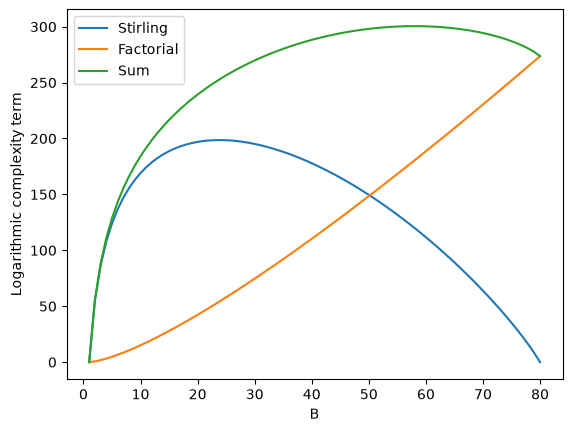

In [144]:
N=Gsbm.number_of_nodes()
logPriors = [np.log(float(stirling(N,k+1,kind=2))) for k in range(N)]
logFactorial=[np.log(factorial(k+1)) for k in range(N)]

plt.plot(np.arange(1,N+1),logPriors,label="Stirling")
plt.plot(np.arange(1,N+1),logFactorial,label="Factorial")
plt.plot(np.arange(1,N+1),np.array(logPriors)+np.array(logFactorial),label="Sum")
plt.xlabel("B")
plt.ylabel("Logarithmic complexity term")
plt.legend()
plt.show()

In [145]:
all_logLs = np.load("SBMlogLs.npy")
all_bbests = np.load("SBMbbests.npy")
Bmax = min(6, len(all_logLs))
logLs = all_logLs[:Bmax]
bbests = all_bbests[:Bmax]

FileNotFoundError: [Errno 2] No such file or directory: 'SBMlogLs.npy'

In [146]:
print("Inferred network with true B. Inferred -log L="+str(logLs[2]))
nx.draw(Gsbm,node_color=bbests[2],pos=layoutSBM)

NameError: name 'logLs' is not defined

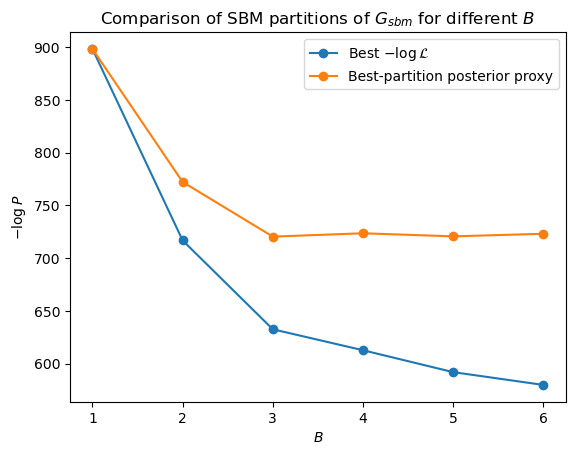

Minimum posterior proxy at B = 3


In [60]:
posterior_proxy = np.array(logLs) + np.array(logFactorial[:Bmax]) + np.array(logPriors[:Bmax])

plt.plot(np.arange(1, Bmax+1), logLs, "-o", label=r"Best $-\log\mathcal{L}$")
plt.plot(np.arange(1, Bmax+1), posterior_proxy, "-o", label="Best-partition posterior proxy")
plt.ylabel(r"$-\log P$")
plt.xlabel(r"$B$")
plt.title(r"Comparison of SBM partitions of $G_{sbm}$ for different $B$")
plt.legend()
plt.show()

print("Minimum posterior proxy at B =", np.argmin(posterior_proxy) + 1)


The best-partition posterior proxy is minimized at the planted value $B=3$ among the values shown. The margin is small, illustrating that this approximation and a finite greedy search need not provide decisive evidence for $B$.


## Exercise 7. Inferring $B$ and $\vec{b}$ in an SBM


In this question, reproduce the Bayesian model-comparison calculation above for another network, $G_{sbm2}$.

Construct $G_{sbm2}$ from an SBM with two groups of 20 and 50 nodes. The within-group connection probabilities are $15\%$ and $20\%$, and the between-group probability is $1\%$. Generate it with `nx.stochastic_block_model()` and random seed 13.

a) Plot $G_{sbm2}$ with nodes coloured according to their planted groups.

For $B=2$, the printed comparison checks the planted partition up to label permutation. For $B=3$, the contingency table shows how the extra inferred block subdivides the planted groups to fit finite-sample fluctuations.


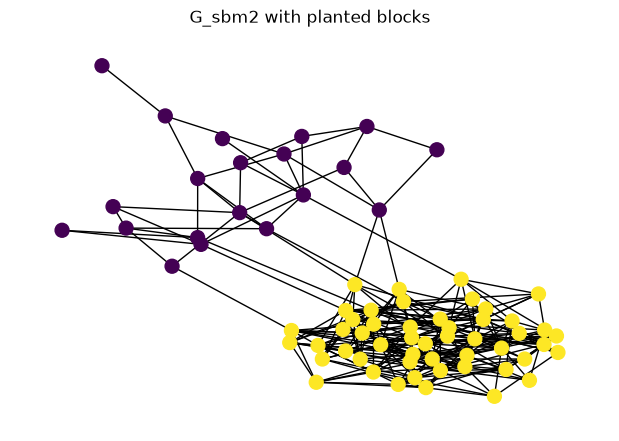

In [193]:
sizes2 = [20, 50]

P2 = [[0.15, 0.01],
      [0.01, 0.20]]

Gsbm2 = nx.stochastic_block_model(sizes2, P2, seed=SEED)

btrue2 = np.array([0]*sizes2[0] + [1]*sizes2[1])

layoutSBM2 = nx.spring_layout(Gsbm2,seed=13)

plt.figure(figsize=(6, 4))
nx.draw(Gsbm2, node_color=btrue2, pos=layoutSBM2, node_size=100)
plt.title("G_sbm2 with planted blocks")
plt.show()

b) Compute the best partitions for $B=1,\ldots,6$.

In [226]:
def random_partition(N, B, rng):
    if B == 1:
        return np.zeros(N, dtype=int)
    while True:
        b = rng.integers(B, size=N)
        if len(np.unique(b)) == B:
            return b

bbests2 = []
LogLs2 = []

for B in range(1,7):
    b_init = random_partition(Gsbm2.number_of_nodes(), B, rng)
    b_final, nll_history, partition_history, accepted = mcmc_partition_search(Gsbm2, B, b_init, n_steps=5000, seed=SEED)
    best_idx = np.argmin(nll_history)
    best_nll = nll_history[best_idx]
    best_b = partition_history[best_idx]

    bbests2.append(best_b.copy())
    LogLs2.append(best_nll)
    print(f"Best NLL for B={B}: {best_nll}")

Best NLL for B=1: 858.2496944341165
Best NLL for B=2: 733.1859180923556
Best NLL for B=3: 701.9465901806775
Best NLL for B=4: 695.9055846993825
Best NLL for B=5: 669.1378251305545
Best NLL for B=6: 667.2157340893147


c) Plot $G_{sbm2}$ using the best partition found for $B=2$. Do you retrieve the planted partition, up to a permutation of the block labels?


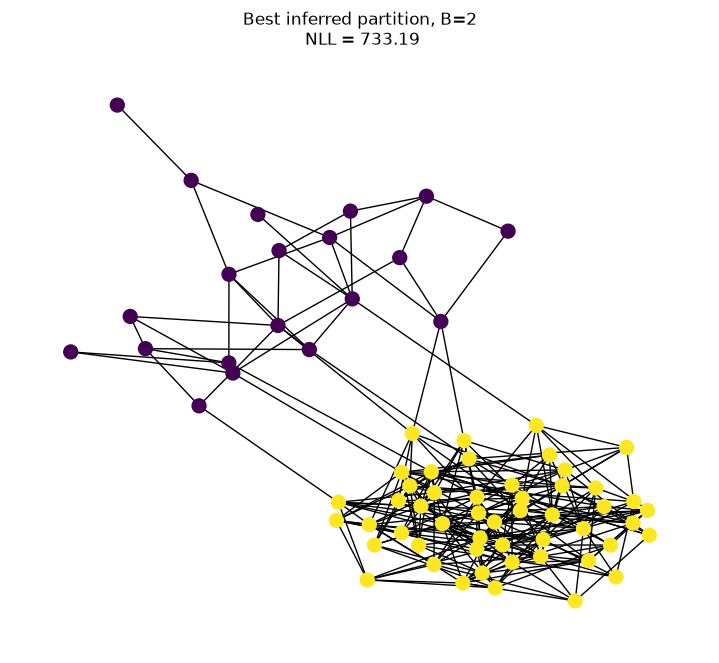

In [206]:
b_best2 = bbests2[1]

plt.figure(figsize=(7, 6))
nx.draw(Gsbm2, node_color=b_best2, pos=layoutSBM2, node_size=100)
plt.title(f"Best inferred partition, B=2\n NLL = {LogLs2[1]:.2f}")
plt.show()

d) Plot $G_{sbm2}$ using the best partition found for $B=3$. Compare it with the planted partition and interpret the result.

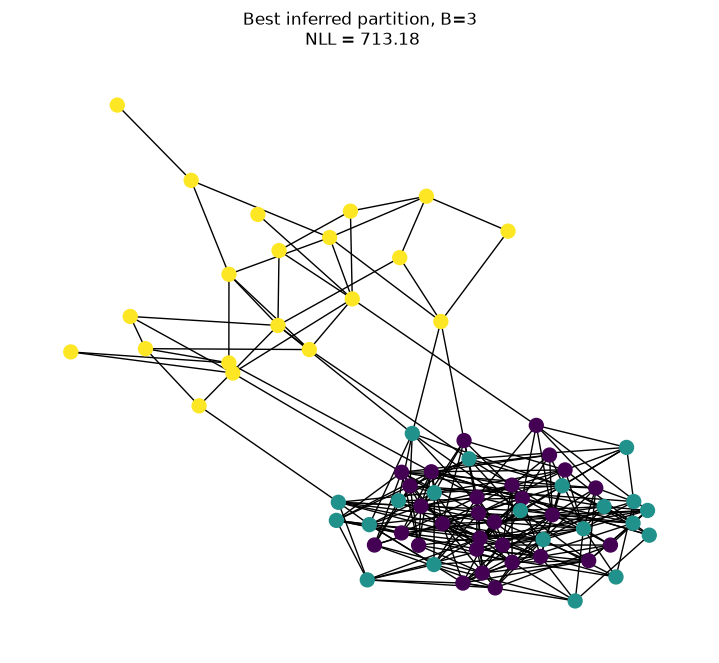

In [207]:
b_best3 = bbests2[2]

plt.figure(figsize=(7, 6))
nx.draw(Gsbm2, node_color=b_best3, pos=layoutSBM2, node_size=100)
plt.title(f"Best inferred partition, B=3\n NLL = {LogLs2[2]:.2f}")
plt.show()

In [208]:
contingency = np.zeros((2, 3), dtype=int)

for true_group, inferred_group in zip(btrue2,b_best3): 
    contingency[true_group, inferred_group] += 1

print(contingency)

[[ 0  0 20]
 [29 21  0]]


e) Plot $-\log P(D\mid\vec{b},B)$ and the best-partition posterior proxy as functions of $B$.

In [216]:
from sympy.functions.combinatorial.numbers import stirling
from scipy.special import gammaln

N2 = Gsbm2.number_of_nodes()

log_stirling = []
log_factorial = []
posterior = []
for B in range(1,7):
    log_stirling.append(np.log(float(stirling(N2, B, kind=2))))
    log_factorial.append(gammaln(B + 1))
    posterior.append(LogLs2[B-1] + log_factorial[B-1] + log_stirling[B-1])

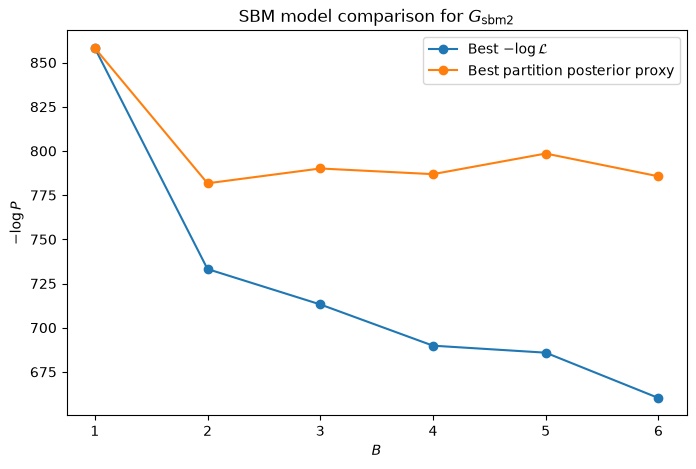

In [224]:
plt.figure(figsize=(8, 5))

plt.plot(np.arange(1, 7), LogLs2, "-o", label=r"Best $-\log \mathcal{L}$")
plt.plot(np.arange(1, 7), posterior, "-o", label="Best partition posterior proxy")

plt.xlabel(r"$B$")
plt.ylabel(r"$-\log P$")
plt.title(r"SBM model comparison for $G_{\rm sbm2}$")
plt.xticks(np.arange(1, 7))
plt.legend()
plt.show()

In [222]:
best_B = range(1,7)[np.argmin(posterior)]

print("Minimum posterior proxy at B =",best_B)

Minimum posterior proxy at B = 2
